In [ ]:
Name Shivam Nangare
Roll no ACT 45

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.optimizers import Adam

In [ ]:
#load data set
(x_train,y_train), (x_test,y_test)= boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("shape oif x_trainj(Indipendent Variable):",x_train.shape)
print("shape oif y_trainj(Indipendent Variable):",y_train.shape)



shape oif x_trainj(Indipendent Variable): (404, 13)
shape oif y_trainj(Indipendent Variable): (404,)


In [ ]:
print("\nFirst 5 rows of x_train (Indipendent Variable):")


First 5 rows of x_train (Indipendent Variable):


In [ ]:
#Featuer scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
print(x_train[:5])

[[-0.27224633 -0.48361547 -0.43576161 -0.25683275 -0.1652266  -0.1764426
   0.81306188  0.1166983  -0.62624905 -0.59517003  1.14850044  0.44807713
   0.8252202 ]
 [-0.40342651  2.99178419 -1.33391162 -0.25683275 -1.21518188  1.89434613
  -1.91036058  1.24758524 -0.85646254 -0.34843254 -1.71818909  0.43190599
  -1.32920239]
 [ 0.1249402  -0.48361547  1.0283258  -0.25683275  0.62864202 -1.82968811
   1.11048828 -1.18743907  1.67588577  1.5652875   0.78447637  0.22061726
  -1.30850006]
 [-0.40149354 -0.48361547 -0.86940196 -0.25683275 -0.3615597  -0.3245576
  -1.23667187  1.10717989 -0.51114231 -1.094663    0.78447637  0.44807713
  -0.65292624]
 [-0.0056343  -0.48361547  1.0283258  -0.25683275  1.32861221  0.15364225
   0.69480801 -0.57857203  1.67588577  1.5652875   0.78447637  0.3898823
   0.26349695]]


In [ ]:
model= Sequential()
model.add(Dense(64,activation='relu',input_shape=(x_train.shape[1],)))
model.add(Dense(32,activation='relu'))
model.add(Dense(1)) # linear output for regression

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mse']
    )

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=40,
    validation_data=(x_test,y_test),
    #verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5578 - mse: 0.5578 - val_loss: 14.4055 - val_mse: 14.4055
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3829 - mse: 1.3829 - val_loss: 14.2758 - val_mse: 14.2758
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0057 - mse: 1.0057 - val_loss: 15.7124 - val_mse: 15.7124
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8938 - mse: 0.8938 - val_loss: 14.6945 - val_mse: 14.6945
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8937 - mse: 0.8937 - val_loss: 14.8164 - val_mse: 14.8164
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8958 - mse: 0.8958 - val_loss: 14.4314 - val_mse: 14.4314
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7160 - mse: 0.7160 - val_loss: 14.9303 - val_mse: 14.9303
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5134 - mse: 0.5134 - val_loss: 14.4145 - val_mse: 14.4145
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
#evaluate the model
test_loss, test_mae = model.evaluate(x_test,y_test)
print("Test Mean Squared Error:",test_loss)
print("Test Mean Absoluate Error:",test_mae)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.4630 - mse: 10.4630
Test Mean Squared Error: 15.134045600891113
Test Mean Absoluate Error: 15.134045600891113


In [ ]:
#predictions
predictions = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [ ]:
for i in range (5):
  print(f"Actual price: {y_test[i]: .2f} | predicated price:{predictions[i][0]: .2f}")

Actual price:  7.20 | predicated price: 8.71
Actual price:  18.80 | predicated price: 18.88
Actual price:  19.00 | predicated price: 20.83
Actual price:  27.00 | predicated price: 29.68
Actual price:  22.20 | predicated price: 25.22


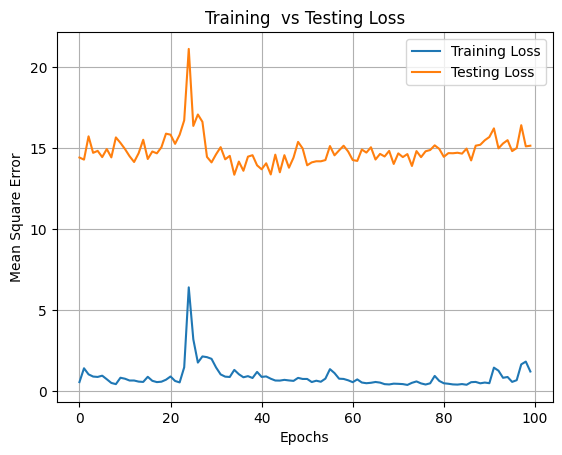

In [ ]:
#Traning & Testing loss
plt.figure()
plt.plot(history.history['loss'], label ='Training Loss')
plt.plot(history.history['val_loss'],label ='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Square Error')
plt.title('Training  vs Testing Loss')
plt.legend()
plt.grid(True)
plt.show()

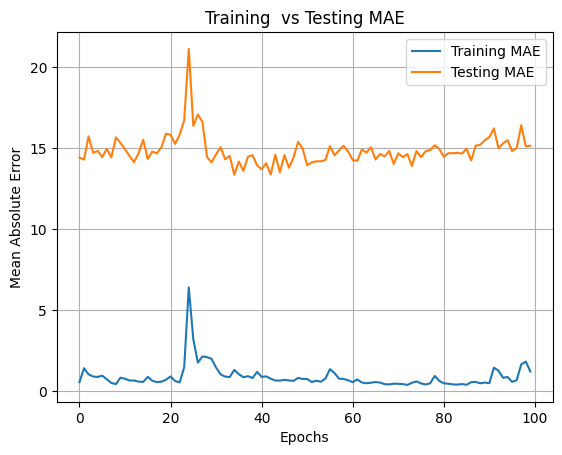

In [ ]:
#traning and tessing MAE
#Traning & Testing loss
plt.figure()
plt.plot(history.history['mse'], label ='Training MAE')
plt.plot(history.history['val_mse'],label ='Testing MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.title('Training  vs Testing MAE')
plt.legend()
plt.grid(True)
plt.show()


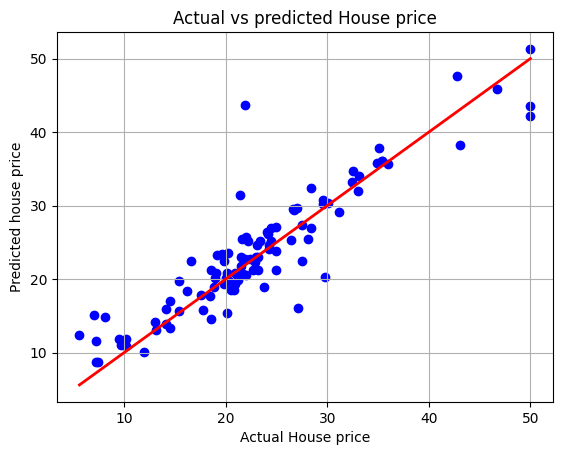

In [ ]:
#linear graph (actual vs predicted)
plt.figure()
plt.scatter(y_test, predictions, color='blue' )
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color='red',linewidth=2)
plt.xlabel('Actual House price')
plt.ylabel('Predicted house price')
plt.title('Actual vs predicted House price')
plt.grid(True)
plt.show()
